# Assignment 10 - Assignment
## Topic: K-Means Clustering

### Question 1
Load the Mall Customers dataset from the CSV file. Display the first 10 rows and identify the input features and target variable.

Dataset: [kaggle.com](https://www.kaggle.com/datasets/mosesmoncy/mall-customerscsv/data)

In [1]:
import pandas as pd

# Load the Mall Customers dataset
df = pd.read_csv('Assignment_10b.csv')

# Display first 10 rows
print(df.head(10).to_string())

# Identify features
print('\nShape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nFeatures available for clustering:')
print('  - Age')
print('  - Annual Income (k$)')
print('  - Spending Score (1-100)')
print('\nNote: CustomerID is just an identifier and Gender is categorical.')

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72

Shape: (200, 5)

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Features available for clustering:
  - Age
  - Annual Income (k$)
  - Spending Score (1-100)

Note: CustomerID 

### Question 2
Select two features — Annual Income (k$) and Spending Score (1-100) — for clustering.

In [2]:
print('----- Selected Features -----')

# Select two features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

print('\nFeature 1: Annual Income (k$)')
print('Feature 2: Spending Score (1-100)')
print('\nThese two features are chosen because they directly reflect')
print('customer purchasing power and spending behaviour.')
print('\nShape of selected feature matrix:', X.shape)
print()
print(df[['Annual Income (k$)', 'Spending Score (1-100)']].head(10).to_string())

----- Selected Features -----

Feature 1: Annual Income (k$)
Feature 2: Spending Score (1-100)

These two features are chosen because they directly reflect
customer purchasing power and spending behaviour.

Shape of selected feature matrix: (200, 2)

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40
5                  17                      76
6                  18                       6
7                  18                      94
8                  19                       3
9                  19                      72


### Question 3
Apply K-Means clustering with K = 5 on the selected features. Print the cluster labels and cluster centroids.

In [3]:
from sklearn.cluster import KMeans

print('----- K-Means Clustering (K=5) -----')

# Apply K-Means with K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

print('\nK-Means Model Fitted Successfully.')
print('\nCluster Labels (first 20):', cluster_labels[:20].tolist())
print('\nCluster Centroids:')
for i, c in enumerate(centroids):
    print(f'  Cluster {i}: Annual Income = {c[0]:.2f} k$, Spending Score = {c[1]:.2f}')

----- K-Means Clustering (K=5) -----

K-Means Model Fitted Successfully.

Cluster Labels (first 20): [4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2]

Cluster Centroids:
  Cluster 0: Annual Income = 55.30 k$, Spending Score = 49.52
  Cluster 1: Annual Income = 86.54 k$, Spending Score = 82.13
  Cluster 2: Annual Income = 25.73 k$, Spending Score = 79.36
  Cluster 3: Annual Income = 88.20 k$, Spending Score = 17.11
  Cluster 4: Annual Income = 26.30 k$, Spending Score = 20.91


### Question 4
Plot a scatter plot showing the K-Means clusters and mark the cluster centroids.

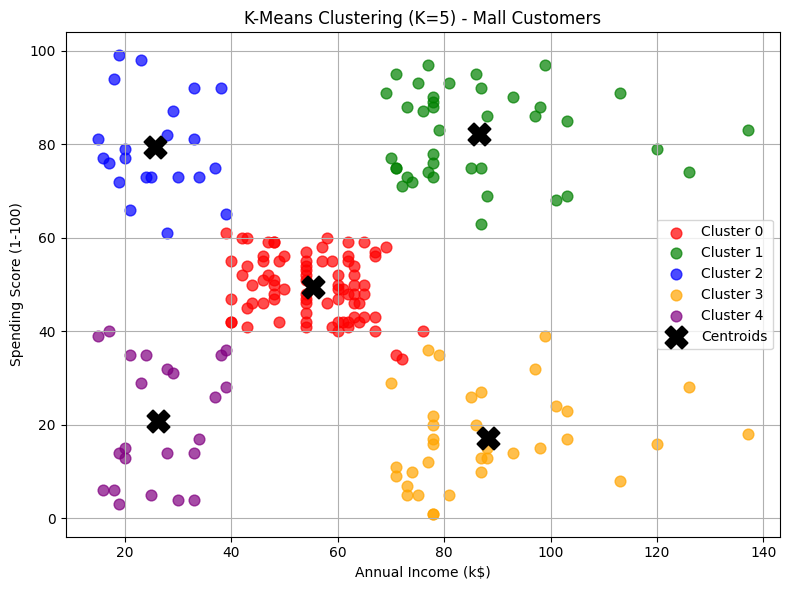

In [4]:
import matplotlib.pyplot as plt

colors = ['red', 'green', 'blue', 'orange', 'purple']

plt.figure(figsize=(8, 6))
for c in range(5):
    mask = cluster_labels == c
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[c],
                label=f'Cluster {c}', alpha=0.7, s=60)

# Mark centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X',
            s=250, linewidths=1.5, label='Centroids', zorder=5)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering (K=5) - Mall Customers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Question 5
Compare the cluster labels from K-Means with the Gender attribute. Plot both side by side and summarise each cluster.

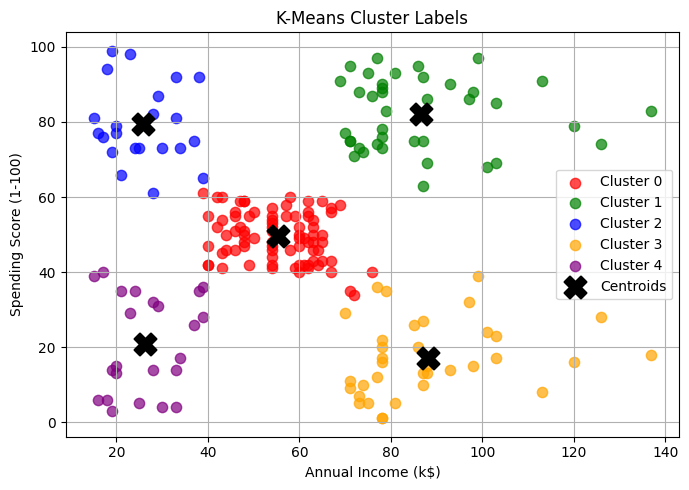

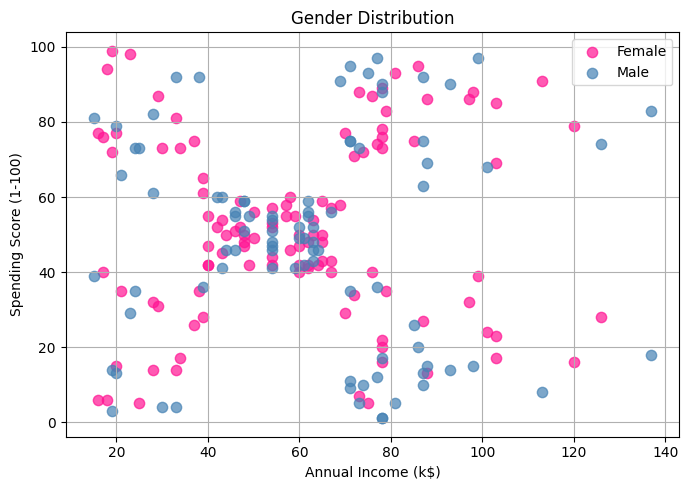

----- Comparison: K-Means Clusters vs Gender -----

Cluster Summary (mean values per cluster):
         Avg Age  Avg Income (k$)  Avg Spending Score
Cluster                                              
0          42.72            55.30               49.52
1          32.69            86.54               82.13
2          25.27            25.73               79.36
3          41.11            88.20               17.11
4          45.22            26.30               20.91

Gender distribution per cluster:
Cluster  Gender
0        Female    48
         Male      33
1        Female    21
         Male      18
2        Female    13
         Male       9
3        Female    16
         Male      19
4        Female    14
         Male       9

Note: Since this dataset has no definitive ground-truth cluster labels,
      Gender is used as a reference attribute for comparison.


In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode Gender for reference comparison
le = LabelEncoder()
gender_labels = le.fit_transform(df['Gender'])   # Female=0, Male=1
gender_colors = ['deeppink', 'steelblue']
gender_names  = le.classes_

# --- Plot 1: K-Means Clusters ---
fig1, ax1 = plt.subplots(figsize=(7, 5))
for c in range(5):
    mask = cluster_labels == c
    ax1.scatter(X[mask, 0], X[mask, 1], c=colors[c],
                label=f'Cluster {c}', alpha=0.7, s=55)
ax1.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X',
            s=250, linewidths=1.5, label='Centroids', zorder=5)
ax1.set_xlabel('Annual Income (k$)')
ax1.set_ylabel('Spending Score (1-100)')
ax1.set_title('K-Means Cluster Labels')
ax1.legend()
ax1.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: Gender Distribution ---
fig2, ax2 = plt.subplots(figsize=(7, 5))
for g in range(2):
    mask = gender_labels == g
    ax2.scatter(X[mask, 0], X[mask, 1],
                c=gender_colors[g], label=gender_names[g],
                alpha=0.7, s=55)
ax2.set_xlabel('Annual Income (k$)')
ax2.set_ylabel('Spending Score (1-100)')
ax2.set_title('Gender Distribution')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

# Cluster summary table
comp_df = df[['CustomerID', 'Gender', 'Age',
              'Annual Income (k$)', 'Spending Score (1-100)']].copy()
comp_df['Cluster'] = cluster_labels
summary = comp_df.groupby('Cluster')[['Age', 'Annual Income (k$)',
                                       'Spending Score (1-100)']].mean().round(2)
summary.columns = ['Avg Age', 'Avg Income (k$)', 'Avg Spending Score']
print('----- Comparison: K-Means Clusters vs Gender -----')
print('\nCluster Summary (mean values per cluster):')
print(summary.to_string())
print('\nGender distribution per cluster:')
print(comp_df.groupby(['Cluster', 'Gender']).size().to_string())
print('\nNote: Since this dataset has no definitive ground-truth cluster labels,')
print('      Gender is used as a reference attribute for comparison.')

### Question 6
Calculate and print the Adjusted Rand Index (ARI) to evaluate clustering performance.

In [6]:
from sklearn.metrics import adjusted_rand_score

print('----- Adjusted Rand Index (ARI) -----')

# ARI between K-Means clusters and Gender labels
ari = adjusted_rand_score(gender_labels, cluster_labels)

print(f'\nARI Score (K-Means clusters vs Gender): {ari:.4f}')
print('\nInterpretation:')
print('  ARI = 1.0  → Perfect match with reference labels')
print('  ARI = 0.0  → No better than random assignment')
print('  ARI < 0.0  → Worse than random assignment')
print(f'\nARI = {ari:.4f} suggests that the K-Means clusters are')
print('largely independent of gender — which is expected, since')
print('clustering is driven by income and spending behaviour, not gender.')
print('\nA better evaluation for this dataset is the Within-Cluster Sum of')
print('Squares (Inertia), which K-Means minimises internally:')
print(f'  Inertia (WCSS): {kmeans.inertia_:.2f}')

----- Adjusted Rand Index (ARI) -----

ARI Score (K-Means clusters vs Gender): -0.0006

Interpretation:
  ARI = 1.0  → Perfect match with reference labels
  ARI = 0.0  → No better than random assignment
  ARI < 0.0  → Worse than random assignment

ARI = -0.0006 suggests that the K-Means clusters are
largely independent of gender — which is expected, since
clustering is driven by income and spending behaviour, not gender.

A better evaluation for this dataset is the Within-Cluster Sum of
Squares (Inertia), which K-Means minimises internally:
  Inertia (WCSS): 44448.46
